In [1]:
import pandas as pd
monthly_complete = pd.read_csv("monthly_data.csv")
monthly_complete["Date"] = pd.to_datetime(monthly_complete["Date"])

In [2]:
import numpy as np
import matplotlib.pyplot as plt

city = "Pune"
city_df = monthly_complete[monthly_complete["City"] == city]

city_df.set_index("Date", inplace = True)

#Extract crime series
series = city_df["Crime_Count"]

series.head()

Date
2020-01-01    45
2020-02-01    44
2020-03-01    46
2020-04-01    48
2020-05-01    38
Name: Crime_Count, dtype: int64

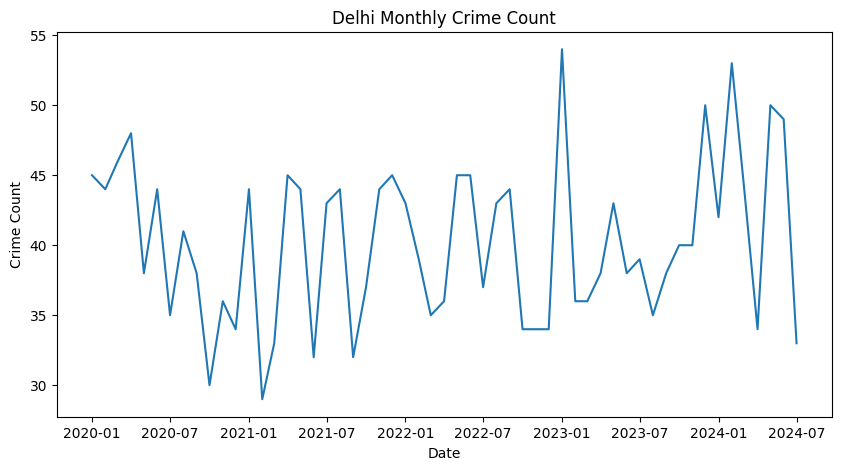

In [3]:
plt.figure(figsize = (10, 5))
plt.plot(series)
plt.title("Delhi Monthly Crime Count")
plt.xlabel("Date")
plt.ylabel("Crime Count")
plt.show()

In [4]:
train = series[:"2023-12-01"]
test = series["2024-01-01":]

print("Training dataset:", len(train))
print("Testing dataset:", len(test))

Training dataset: 48
Testing dataset: 7


In [5]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train,
                order = (1, 1, 1),
                seasonal_order = (1, 1, 1, 12),
                enforce_stationarity = False,
                enforce_invertibility = False)

results = model.fit()

print(results.summary())

d:\Python\Python Files\College Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Python\Python Files\College Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Python\Python Files\College Project\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                        Crime_Count   No. Observations:                   48
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -65.894
Date:                            Wed, 04 Mar 2026   AIC                            141.789
Time:                                    16:46:05   BIC                            147.011
Sample:                                01-01-2020   HQIC                           142.922
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2647      0.475      0.558      0.577      -0.665       1.195
ma.L1         -1.0000   2658.087   

In [6]:
def visualize_model(test, forecast):
    plt.figure(figsize = (10, 5))
    plt.plot(test, label = "Actual 2024 data")
    plt.plot(forecast, label = "Forecast 2024 data")
    plt.legend()
    plt.title("Delhi Crime Forecast")
    plt.show()

In [7]:
forecast = results.predict(start = test.index[0], end = test.index[-1])

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)
print("AIC:", results.aic)

MAE: 6.686221331104546
RMSE: 7.40097992704491
AIC: 141.78850517837938


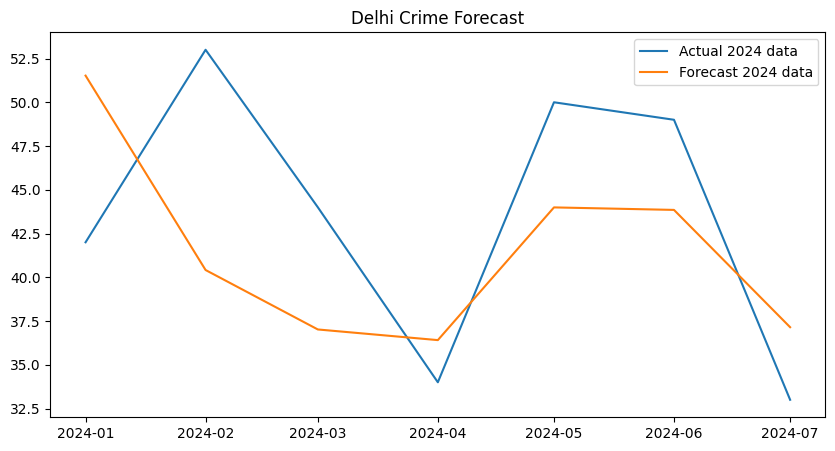

In [9]:
visualize_model(test, forecast)

In [10]:
from statsmodels.tsa.stattools import adfuller

#Augmented dickey-fuller test to check whether data is stationery or not
test_result = adfuller(series)

print(test_result[1])

9.473693396300787e-07


MAE: 8.674095948543588
RMSE: 9.542252630893461
AIC: 229.93373255466847


d:\Python\Python Files\College Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Python\Python Files\College Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


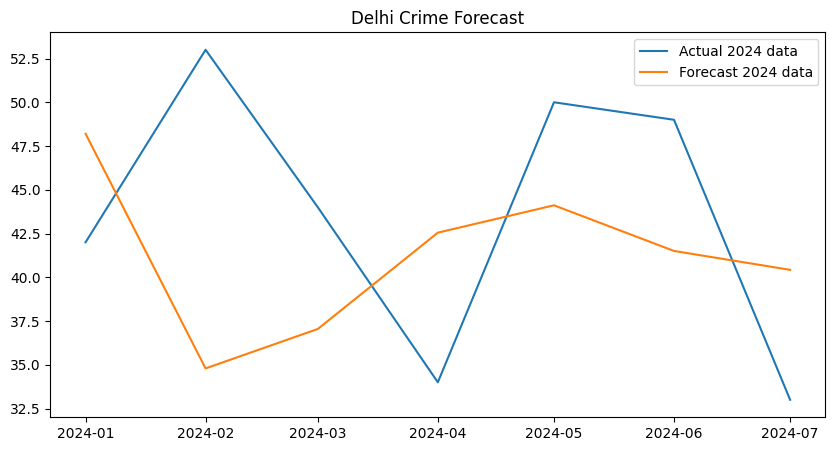

In [11]:
model2 = SARIMAX(train,
                 order = (1, 0, 1),
                 seasonal_order = (1, 0, 1, 12),
                 enforce_stationarity = False,
                 enforce_invertibility = False)

results2 = model2.fit()

forecast2 = results2.predict(start = test.index[0], end = test.index[-1])

mae2 = mean_absolute_error(test, forecast2)
rmse2 = np.sqrt(mean_squared_error(test, forecast2))

print("MAE:", mae2)
print("RMSE:", rmse2)
print("AIC:", results2.aic)

visualize_model(test, forecast2)

d:\Python\Python Files\College Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Python\Python Files\College Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Python\Python Files\College Project\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE: 205.2604392863578
RMSE: 206.77489978773775
AIC: 1439.6646115324847


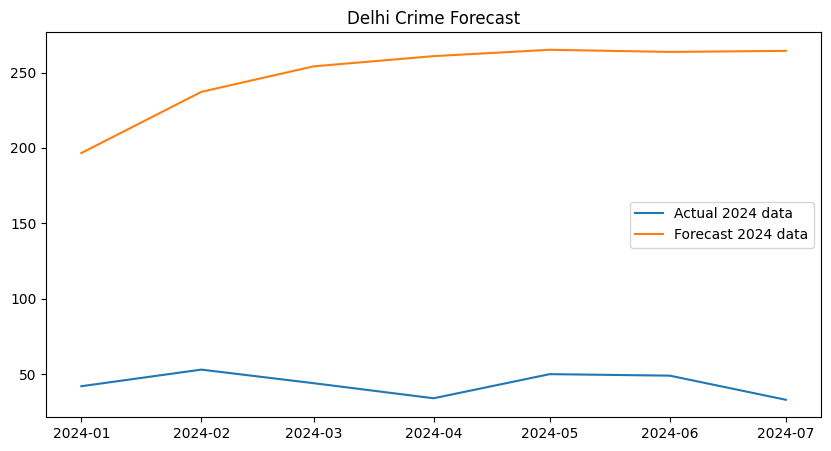

In [12]:
model3 = SARIMAX(train,
                 order=(1,1,1),
                 seasonal_order=(1,0,1,12),
                 enforce_stationarity=False,
                 enforce_invertibility=False)

results3 = model3.fit()

forecast3 = results3.predict(start=test.index[0], end=test.index[-1])

mae3 = mean_absolute_error(test, forecast3)
rmse3 = np.sqrt(mean_squared_error(test, forecast3))

print("MAE:", mae3)
print("RMSE:", rmse3)
print("AIC:", results3.aic)

visualize_model(test, forecast3)

In [13]:

def walk_forward_sarima(monthly_complete, city_name,
                         target_col="Crime_Count",
                         order=(1,1,1),
                         seasonal_order=(1,1,1,12)):
    
    # Filter city data
    df_city = monthly_complete[monthly_complete["City"] == city_name].copy()
    df_city = df_city.sort_values("Date")
    df_city.set_index("Date", inplace=True)
    
    # Define initial training and testing boundaries
    start_train = "2020-01-01"
    end_test = "2024-07-01"
    
    predictions = []
    actuals = []
    prediction_dates = []
    
    current_test_date = pd.to_datetime("2024-01-01")
    
    while current_test_date <= pd.to_datetime(end_test):
        
        # Define expanding training set
        train_data = df_city.loc[start_train : current_test_date - pd.DateOffset(months=1)][target_col]
        
        # Fit SARIMA
        model = SARIMAX(train_data,
                        order=order,
                        seasonal_order=seasonal_order,
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        
        model_fit = model.fit(disp=False)
        
        # Forecast next month
        forecast = model_fit.forecast(steps=1)
        
        # Store results
        predictions.append(forecast.iloc[0])
        actual_value = df_city.loc[current_test_date][target_col]
        actuals.append(actual_value)
        prediction_dates.append(current_test_date)
        
        # Move to next month
        current_test_date += pd.DateOffset(months=1)
    
    mae = mean_absolute_error(actuals, predictions)
    rmse = np.sqrt(mean_squared_error(actuals, predictions))

    actuals_arr = np.array(actuals)
    pred_arr = np.array(predictions)

    mape = np.mean(np.abs((actuals_arr - pred_arr) / actuals_arr)) * 100 #Mean Absolute Percentage Error
    
    return {
        "City": city_name,
        "Date": prediction_dates,
        "Actual": actuals,
        "Predicted": predictions,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }
    


In [14]:
all_results = []

for city in monthly_complete["City"].unique():
    city_result = walk_forward_sarima(monthly_complete, city)
    all_results.append(city_result)

performance_df = pd.DataFrame(all_results)[["City", "MAE", "RMSE", "MAPE"]]
performance_df.sort_values("MAE", inplace = True)
performance_df.set_index("City", inplace = True)

print(performance_df)

d:\Python\Python Files\College Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Python\Python Files\College Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Python\Python Files\College Project\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
d:\Python\Python Files\College Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Pytho

                     MAE        RMSE        MAPE
City                                            
Varanasi        1.412805    1.892254   24.642926
Srinagar        1.931514    2.240233   29.036320
Indore          1.938364    2.676949   13.340028
Faridabad       2.235664    2.685946   31.469768
Kanpur          2.306046    3.110785   11.629530
Vasai           2.650942    3.173932  101.351139
Rajkot          2.687334    3.152671   64.317588
Kalyan          2.775148    3.583384   66.902774
Agra            3.890424    4.272057   28.281484
Nagpur          4.538942    5.537958   30.810924
Meerut          4.698327    5.275388   67.431246
Ghaziabad       4.825903    5.438471   45.013335
Ludhiana        5.216176    6.044347   40.664421
Bhopal          5.553125    6.115677   44.249077
Ahmedabad       6.223796    7.866337   22.139655
Surat           6.305462    6.685443   31.048147
Chennai         6.359791    8.231426   17.101823
Patna           7.235155    9.607255   41.964738
Jaipur          7.63

d:\Python\Python Files\College Project\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


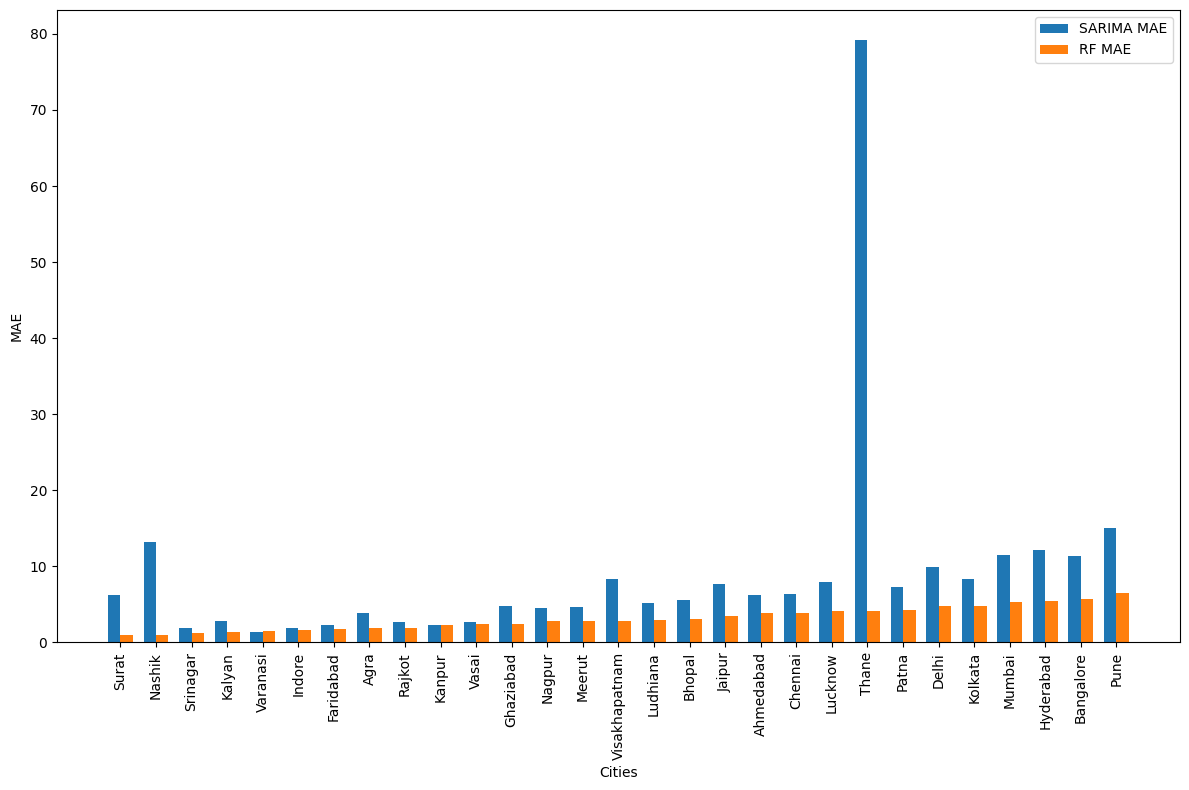

In [15]:
rolling_rf_performance = pd.read_csv("performance.csv")
rolling_rf_performance = rolling_rf_performance.rename(columns = {"MAE": "RF_MAE", "RMSE": "RF_RMSE", "MAPE": "RF_MAPE"})
rolling_rf_performance = rolling_rf_performance.merge(performance_df, on = "City")

rolling_rf_performance
x = np.arange(len(rolling_rf_performance["City"]))  # the label locations
width = 0.35  # the width of the bars

# 3. Create the plot and plot bars
fig, ax = plt.subplots(figsize=(12, 8))

# Bars for the first dataset
rects1 = ax.bar(x - width/2, rolling_rf_performance["MAE"], width, label='SARIMA MAE')

# Bars for the second dataset (offset by half a width)
rects2 = ax.bar(x + width/2, rolling_rf_performance["RF_MAE"], width, label='RF MAE')

# 4. Customize the Chart
ax.set_ylabel('MAE')
ax.set_xlabel('Cities')
#ax.set_title('Comparison of SARIMA and RF rolling forward models')
ax.set_xticks(x, rolling_rf_performance["City"], rotation = 90) # Set the tick locations and labels
ax.legend() # Display the legend

# Ensure the layout is tight and prevent labels from clipping
plt.tight_layout()

This chart clearly demonstrates the Rolling Random Forest performs consistently better than SARIMA in predicting forecasted values

In [16]:
print("Rolling Random Forest Avg MAE:", rolling_rf_performance["RF_MAE"].mean())
print("Rolling SARIMA Avg MAE:", rolling_rf_performance["MAE"].mean())

percentage_diff = (rolling_rf_performance["MAE"].mean() - rolling_rf_performance["RF_MAE"].mean()) / rolling_rf_performance["RF_MAE"].mean() * 100

print("Percentage Increase in Error:", percentage_diff, "%")

Rolling Random Forest Avg MAE: 3.1522033026374476
Rolling SARIMA Avg MAE: 8.879434140025042
Percentage Increase in Error: 181.68976704629495 %
